In [50]:
import os
import zipfile
import cv2
import numpy as np
from collections import Counter
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [51]:
# Pre-install zip dataset, move it to the root folder and unpack
print(os.path.exists('cardetection.zip'))
with zipfile.ZipFile("cardetection.zip", 'r') as zip_ref:
    zip_ref.extractall("cardetection")

True


In [52]:
# Dataset structure
data_path = "cardetection/car"
print(os.listdir(data_path))

['README.roboflow.txt', 'valid', 'README.dataset.txt', 'test', 'data.yaml', 'train']


In [53]:
# How many train images?
train_images_path = os.path.join(data_path, "train/images")
train_image_files = [f for f in os.listdir(train_images_path) if f.endswith(('.jpg','.png','.jpeg'))]
print("Train images:", len(train_image_files))

Train images: 3530


In [54]:
# How many test images?
test_images_path = os.path.join(data_path, "test/images")
test_image_files = [f for f in os.listdir(test_images_path) if f.endswith(('.jpg','.png','.jpeg'))]
print("Test images:", len(test_image_files))

Test images: 638


In [55]:
# How many valid images?
valid_images_path = os.path.join(data_path, "valid/images")
valid_image_files = [f for f in os.listdir(valid_images_path) if f.endswith(('.jpg','.png','.jpeg'))]
print("Test images:", len(valid_image_files))

Test images: 801


In [56]:
# Check sizes
sizes = []

for file in train_image_files:
    img = cv2.imread(os.path.join(train_images_path, file))
    if img is not None:
        h, w, c = img.shape
        sizes.append((w, h))

sizes = np.array(sizes)

print("Minimum width:", sizes[:,0].min())
print("Maximum width:", sizes[:,0].max())
print("Minimum height:", sizes[:,1].min())
print("Maximum height:", sizes[:,1].max())

Minimum width: 416
Maximum width: 416
Minimum height: 416
Maximum height: 416


In [57]:
# Check formats
formats = Counter([f.split('.')[-1].lower() for f in train_image_files + test_image_files + valid_image_files])
print("Encountered formats:", formats)

Encountered formats: Counter({'jpg': 4969})


In [58]:
class RoadDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.images_dir = os.path.join(root_dir, "images")
        self.labels_dir = os.path.join(root_dir, "labels")
        self.image_files = [
            f for f in os.listdir(self.images_dir)
            if f.endswith(('.jpg', '.jpeg', '.png'))
        ]
        self.transforms = transforms
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        label_path = os.path.join(
            self.labels_dir,
            img_name.replace(".jpg", ".txt").replace(".png", ".txt")
        )
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape
        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                lines = f.readlines()
            for line in lines:
                class_id, x_center, y_center, width, height = map(float, line.strip().split())
                x_center *= w
                y_center *= h
                width *= w
                height *= h
                x_min = x_center - width / 2
                y_min = y_center - height / 2
                x_max = x_center + width / 2
                y_max = y_center + height / 2
                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(int(class_id))
        if self.transforms:
            transformed = self.transforms(
                image=image,
                bboxes=boxes,
                labels=labels
            )
            image = transformed['image']
            boxes = torch.tensor(transformed['bboxes'], dtype=torch.float32)
            labels = torch.tensor(transformed['labels'], dtype=torch.int64)
        else:
            image = ToTensorV2()(image=image)['image']
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }
        return image, target

In [59]:
transform = A.Compose(
    [
        A.LongestMaxSize(max_size=512),
        A.PadIfNeeded(512, 512),
        A.HorizontalFlip(p=0.5),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),ToTensorV2()
    ],
    bbox_params=A.BboxParams(format='pascal_voc',label_fields=['labels'])
)

val_test_transform = A.Compose(
    [
        A.LongestMaxSize(max_size=512),
        A.PadIfNeeded(512, 512),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),
        ToTensorV2()
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels']
    )
)

In [60]:
train_dataset = RoadDataset("cardetection/car/train", transforms=transform)
val_dataset = RoadDataset("cardetection/car/valid", transforms=val_test_transform)
test_dataset = RoadDataset("cardetection/car/test", transforms=val_test_transform)

In [61]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

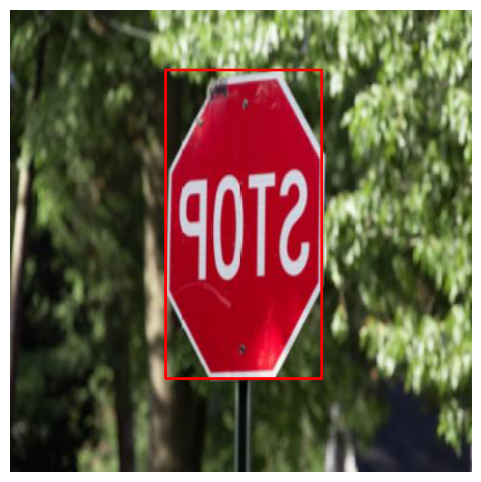

In [62]:
image, target = train_dataset[0]
    
boxes = target["boxes"]

image = image.permute(1, 2, 0).cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image = std * image + mean
image = np.clip(image, 0, 1)
image_copy = image.copy()
h, w, _ = image_copy.shape

for box in boxes:
    x_min, y_min, x_max, y_max = box.tolist()
    cv2.rectangle(
        image_copy,
        (int(x_min), int(y_min)),
        (int(x_max), int(y_max)),
        (1, 0, 0),
        2
    )

plt.figure(figsize=(6,6))
plt.imshow(image_copy)
plt.axis("off")
plt.show()